In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 113.7 MB/s eta 0:00:00


In [3]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd
import warnings
import os
import rasterio
from prophet import Prophet
warnings.filterwarnings('ignore')

In [4]:
import ee
ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

In [6]:
gdf_aoi = gpd.read_file('/content/drive/MyDrive/AlvaroSampaio/GeoScan/Prophet_pred/AOI.shp')
gdf_aoi.head()

,id,geometry
0,NaN,"POLYGON ((-8444177.753 -1566802.441, -8444125...."


In [7]:
#Vamos converter o GeoDataFrame para uma FeatureCollection para pegar as coleções de imagem da área
fc = geemap.geopandas_to_ee(gdf_aoi)

In [8]:
S2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)).filterDate('2023-01-01','2024-12-31').filterBounds(fc)

In [10]:
#Lets generate a monthly NDVI series
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

S2_coll = S2_coll.map(addNDVI)

In [11]:
!mkdir sentinel_2_by_month

In [12]:
months = ee.List.sequence(1, 12)
years = ee.List.sequence(2023, 2024)

def monthly(collection):
  img_coll = ee.ImageCollection([])
  for y in years.getInfo():
    for m in months.getInfo():
      filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
      filtered = filtered.median().clip(fc.geometry())
      img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).format('YYYY-MM-dd').getInfo()))
      img_coll = img_coll.select('NDVI')
  return img_coll

In [13]:
monthly_s2_collection = monthly(S2_coll)
print('Total number of images :', monthly_s2_collection.size().getInfo())

Total number of images : 24


In [14]:
Map = geemap.Map()
Map.centerObject(fc,14)

# Function to display an image on the map
def display_image(image):
  vis_params = {
      'bands': 'NDVI',
      'min': 0,
      'max': 1,
      'palette': ['red', 'yellow', 'green']
  }
  Map.addLayer(image, vis_params, str(image.get('system:time_start').getInfo()))

# Iterate through the yearly image collection and display each image
for i in range(monthly_s2_collection.size().getInfo()):
    image = ee.Image(monthly_s2_collection.toList(monthly_s2_collection.size()).get(i))
    display_image(image.select('NDVI'))


Map

Map(center=[-13.931778462791062, -75.84784554504527], controls=(WidgetControl(options=['position', 'transparen…

In [15]:
geemap.ee_export_image_collection(
    monthly_s2_collection,
    out_dir="./sentinel_2_by_month",
    scale=20,
    crs='EPSG:4326',
    region=fc.geometry(),
    filenames= monthly_s2_collection.aggregate_array("system:time_start").getInfo(),
    file_per_band=False,
    timeout=300,
    proxies=None
)

Total number of images: 24

Exporting 1/24: ./sentinel_2_by_month/2023-01-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-01-01.tif


Exporting 2/24: ./sentinel_2_by_month/2023-02-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-02-01.tif


Exporting 3/24: ./sentinel_2_by_month/2023-03-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-03-01.tif


Exporting 4/24: ./sentinel_2_by_month/2023-04-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-04-01.tif


Exporting 5/24: ./sentinel_2_by_month/2023-05-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-05-01.tif


Exporting 6/24: ./sentinel_2_by_month/2023-06-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-06-01.tif


Exporting 7/24: ./sentinel_2_by_month/2023-07-01.tif
G

In [16]:
geemap.ee_export_image_collection(
    monthly_s2_collection,
    out_dir="./sentinel_2_by_month",
    scale=20,
    crs='EPSG:4326',
    region=fc.geometry(),
    filenames= monthly_s2_collection.aggregate_array("system:time_start").getInfo(),
    file_per_band=False,
    timeout=300,
    proxies=None
)


Total number of images: 24

Exporting 1/24: ./sentinel_2_by_month/2023-01-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-01-01.tif


Exporting 2/24: ./sentinel_2_by_month/2023-02-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-02-01.tif


Exporting 3/24: ./sentinel_2_by_month/2023-03-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-03-01.tif


Exporting 4/24: ./sentinel_2_by_month/2023-04-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-04-01.tif


Exporting 5/24: ./sentinel_2_by_month/2023-05-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-05-01.tif


Exporting 6/24: ./sentinel_2_by_month/2023-06-01.tif
Generating URL ...
Please wait ...
Data downloaded to /content/sentinel_2_by_month/2023-06-01.tif


Exporting 7/24: ./sentinel_2_by_month/2023-07-01.tif
G

In [18]:
im_list = []
index = []
path = '/content/sentinel_2_by_month'
for name in os.listdir(path):
  path_full = os.path.join(path,name)
  ds = rasterio.open(path_full, 'r')
  im = ds.read(1)
  im_list.append(im)
  index.append(name.split('.')[0])

In [19]:
im_list = np.array(im_list)
im_list.shape

(24, 54, 78)

In [20]:
n = im_list.shape[0]
l = im_list.shape[1]
c = im_list.shape[2]
im_data = im_list.reshape(n, l*c)
df_full = pd.DataFrame(im_data, index=index)


In [21]:
df_full.sort_index(inplace=True)

In [22]:
new_test = df_full[1485].reset_index()
new_test.rename(columns={"index": "ds", 1485: "y"},inplace=True)
model = Prophet(yearly_seasonality=True)
model.fit(new_test)
forecast = model.make_future_dataframe(periods = 12, freq = 'M')
forecast = model.predict(forecast)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefyffqtl/3o2gwalo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefyffqtl/fxdx59iq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85652', 'data', 'file=/tmp/tmpefyffqtl/3o2gwalo.json', 'init=/tmp/tmpefyffqtl/fxdx59iq.json', 'output', 'file=/tmp/tmpefyffqtl/prophet_model6y3f7_5q/prophet_model-20250826143050.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
14:30:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:31:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:

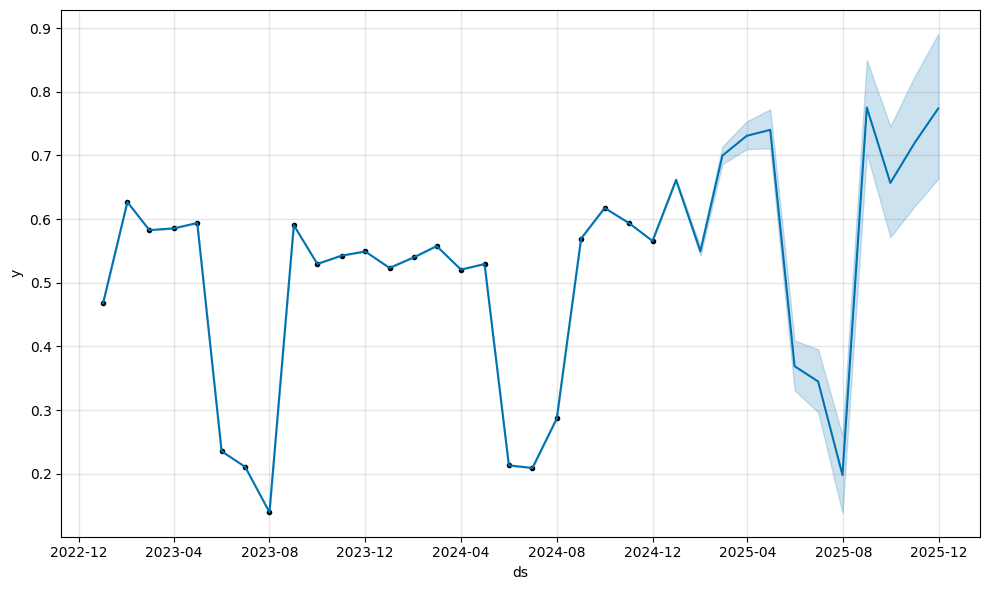

In [23]:
fig1 = model.plot(forecast)


In [24]:
def CreateTimeSeries(id):
    new_df = df_full[id].reset_index()
    new_df.rename(columns={"index": "ds", id: "y"},inplace=True)
    return new_df

In [25]:
def run_prophet(id):
    timeserie = CreateTimeSeries(id)
    model = Prophet(yearly_seasonality=True)
    model.fit(timeserie)
    forecast = model.make_future_dataframe(periods = 12, freq = 'M')
    forecast = model.predict(forecast)
    return np.append(np.array([id]),forecast['yhat'].values.transpose())

In [ ]:
columns_df = df_full.columns
from multiprocessing import Pool, cpu_count
print(f'Parallelism on {cpu_count()} CPU')
with Pool(cpu_count()) as p:
    predictions1  = list(p.imap(run_prophet, columns_df))

Parallelism on 8 CPU


A saída de streaming foi truncada nas últimas 5000 linhas.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefyffqtl/54jeybtb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpefyffqtl/j0gqmkdc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37677', 'data', 'file=/tmp/tmpefyffqtl/54jeybtb.json', 'init=/tmp/tmpefyffqtl/j0gqmkdc.json', 'output', 'file=/tmp/tmpefyffqtl/prophet_models4gqoz6p/prophet_model-20250826144428.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
14:44:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:44:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:

In [ ]:
predictions1 = np.array(predictions1)
predictions1.shape
predictions1

In [ ]:
date_range = pd.date_range(start='2023-01-01', periods=36, freq='MS')
date_range = date_range.strftime('%Y-%m-%d')

In [ ]:
df_results = pd.DataFrame(predictions1[:,1:], columns=date_range)
df_results

In [ ]:
future_columns = df_results.columns[10:]

In [ ]:
df_results.columns

In [ ]:
future_columns

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_ndvi_for_date(date_col):
    # Extract NDVI data for the specified date
    ndvi_data = df_results[date_col].values.reshape(l, c)

    # Create the plot
    plt.figure(figsize=(10, 10))  # Adjust figure size as needed
    plt.imshow(ndvi_data, cmap='RdYlGn', vmin=0, vmax=1)  # Use RdYlGn colormap and set limits
    plt.title(f'NDVI for {date_col}')
    plt.colorbar(label='NDVI')
    plt.show()


for col in future_columns:
    plot_ndvi_for_date(col)
